# EDA — Estrategia E3 Intraday (LSTM Ensemble, 30 min)

Análisis exploratorio de datos para la estrategia intradiaria de corto plazo.

**Tickers**: SPY, AAPL, NVDA, QQQ  
**Frecuencia**: barras de 5 minutos  
**Horizonte**: 6 barras (30 min)  
**Lookback**: 96 barras (8 horas ≈ 1 día de trading)  
**Modelo**: LSTM Ensemble (3 miembros)  
**Features**: 9 indicadores intradiarios  
**Datos**: ~100K barras/ticker (~2 años vía Alpaca)

**Diferencias clave vs E1/E2 (diario):**
- Retornos ~100× más pequeños (0.01–0.1% vs 1–10%)
- Estacionalidad intradiaria (U-shape en volumen, picos apertura/cierre)
- Muchas más muestras (~100K vs ~2.5K) → mayor poder estadístico
- Costos de transacción relativamente más altos (20 bps round-trip vs 10 bps)

## 0. Setup

In [21]:
import sys
from pathlib import Path

# Agregar raíz del proyecto al path para poder importar módulos de src/
ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Librerías ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Imports del proyecto ---
from src.utils import load_yaml, project_root
from src.e3.intraday_data import load_ohlcv_csv
from src.e3.build_features import compute_intraday_features, make_target_return

# --- Estilo de gráficos ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (14, 5)

print(f"Project root: {project_root()}")

Project root: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict


In [22]:
# --- Cargar configuración central ---
cfg = load_yaml(project_root() / "src" / "config" / "base.yaml")

E3_TICKERS = cfg["universe"]["tickers_by_strategy"]["e3_intraday"]
E3_CFG = cfg["strategies"]["e3_intraday"]
HORIZON_BARS = E3_CFG["horizon_bars"]     # 6 barras = 30 min
LOOKBACK_BARS = E3_CFG["lookback_bars"]   # 96 barras = 8 horas ≈ 1 día trading
ROUND_TRIP_BPS = cfg["costs"]["intraday_round_trip_bps"]

print(f"Tickers: {E3_TICKERS}")
print(f"Horizonte: {HORIZON_BARS} barras ({HORIZON_BARS * 5} min)")
print(f"Lookback: {LOOKBACK_BARS} barras ({LOOKBACK_BARS * 5 / 60:.1f} horas)")
print(f"Costos: {ROUND_TRIP_BPS} bps round-trip")

Tickers: ['SPY', 'AAPL', 'NVDA', 'QQQ']
Horizonte: 6 barras (30 min)
Lookback: 96 barras (8.0 horas)
Costos: 20 bps round-trip


In [ ]:
# --- Cargar datos OHLCV 5-min congelados para EDA (snapshot reproducible) ---
# Objetivo: que el EDA sea 100% reproducible entre corridas.
# Regla: se crea UNA vez un snapshot local y luego siempre se lee desde ahí.

import hashlib
import json as _json
from datetime import datetime, timezone

source_raw_dir = project_root() / "data" / "raw" / "intraday"
snapshot_root = project_root() / "data" / "snapshots" / "e3_intraday_eda_v1"
manifest_path = snapshot_root / "manifest.json"

def _sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# Crear snapshot solo si no existe. Una vez creado, queda fijo para el EDA.
if not snapshot_root.exists():
    snapshot_root.mkdir(parents=True, exist_ok=True)
    print(f"[SNAPSHOT] Creando snapshot reproducible en: {snapshot_root}")

    file_records = []
    for ticker in E3_TICKERS:
        src = source_raw_dir / f"{ticker}_5m.csv"
        dst = snapshot_root / f"{ticker}_5m.csv"

        if not src.exists():
            raise FileNotFoundError(f"No existe CSV de origen para {ticker}: {src}")

        import shutil
        shutil.copy2(src, dst)

        df_tmp = load_ohlcv_csv(dst)
        file_records.append({
            "ticker": ticker,
            "file": dst.name,
            "rows": int(len(df_tmp)),
            "start": str(df_tmp.index.min()),
            "end": str(df_tmp.index.max()),
            "sha256": _sha256_file(dst),
        })

    manifest = {
        "snapshot_name": "e3_intraday_eda_v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "strategy": "e3_intraday",
        "horizon_bars": HORIZON_BARS,
        "lookback_bars": LOOKBACK_BARS,
        "interval": "5m",
        "tickers": E3_TICKERS,
        "files": file_records,
    }
    manifest_path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"[SNAPSHOT] Manifest guardado: {manifest_path}")
else:
    print(f"[SNAPSHOT] Usando snapshot existente: {snapshot_root}")
    if manifest_path.exists():
        print(f"[SNAPSHOT] Manifest: {manifest_path}")
    else:
        print("[SNAPSHOT] Aviso: no se encontró manifest.json")

# Cargar SIEMPRE desde snapshot (dataset fijo).
data = {}
for ticker in E3_TICKERS:
    path = snapshot_root / f"{ticker}_5m.csv"
    if path.exists():
        data[ticker] = load_ohlcv_csv(path)
        print(f"  {ticker}: {len(data[ticker]):,} barras  ({data[ticker].index[0]} → {data[ticker].index[-1]})")
    else:
        raise FileNotFoundError(f"Falta archivo en snapshot para {ticker}: {path}")

print(f"\nTickers cargados desde snapshot: {len(data)}/{len(E3_TICKERS)}")

---

## 1. Calidad y estructura de los datos

### 1.1 Resumen por ticker

In [24]:
# --- Resumen de calidad de datos por ticker ---
# Para datos intradiarios, las métricas clave son:
#   - Cantidad de barras (más es mejor para LSTM)
#   - Rango de fechas (queremos 2+ años)
#   - % de NaNs y zeros en volume (gaps de mercado cerrado)
#   - Barras por día (esperamos ~78: 6.5h trading × 12 barras/h)

BARS_PER_TRADING_DAY = 78  # 6.5 horas × 12 barras de 5 min

summary_rows = []
for ticker, df_t in data.items():
    close = df_t["close"]
    log_ret = np.log(close / close.shift(1)).dropna()
    n_days = df_t.index.normalize().nunique()

    summary_rows.append({
        "Ticker": ticker,
        "Barras": f"{len(df_t):,}",
        "Días": n_days,
        "Barras/día": f"{len(df_t) / n_days:.1f}",
        "Inicio": str(df_t.index[0])[:10],
        "Fin": str(df_t.index[-1])[:10],
        "NaN close %": f"{df_t['close'].isna().mean():.2%}",
        "Vol=0 %": f"{(df_t['volume'] == 0).mean():.2%}",
        "Ret μ (bps)": f"{log_ret.mean() * 1e4:.2f}",
        "Ret σ (bps)": f"{log_ret.std() * 1e4:.2f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_caption("Resumen de datos 5-min por ticker")

,Ticker,Barras,Días,Barras/día,Inicio,Fin,NaN close %,Vol=0 %,Ret μ (bps),Ret σ (bps)
0,SPY,"104,936",606,173.2,2024-01-02,2026-03-20,0.00%,0.00%,0.03,7.34
1,AAPL,"102,495",605,169.4,2024-01-02,2026-03-20,0.00%,0.00%,0.03,14.17
2,NVDA,"106,183",605,175.5,2024-01-02,2026-03-20,0.00%,0.00%,0.12,22.93
3,QQQ,"105,884",605,175.0,2024-01-02,2026-03-20,0.00%,0.00%,0.03,9.55


### 1.2 Missing data heatmap

Visualización de valores nulos por ticker y columna. En datos intradiarios, los nulls suelen aparecer por gaps de mercado (feriados, pre/post-market) o problemas de descarga.

In [ ]:
# --- Heatmap de valores nulos ---
# Construimos una matriz donde cada fila es un ticker y cada columna
# es una columna OHLCV. La celda indica el nro de nulls.

null_matrix = pd.DataFrame(
    {ticker: df.isnull().sum() for ticker, df in data.items()}
).T  # (tickers × columnas)

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    null_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Cantidad de nulls"},
)
ax.set_title("Valores nulos por ticker y columna (OHLCV)", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

total_nulls = null_matrix.values.sum()
print(f"\nTotal de valores nulos en todo el dataset: {total_nulls}")
if total_nulls == 0:
    print("✓ Dataset limpio — sin valores nulos.")

### 1.3 Distribución de barras por hora del día

Esperamos una distribución relativamente uniforme durante el horario de mercado (9:30-16:00 ET = 13:30-20:00 UTC), con posibles picos en la apertura y el cierre.

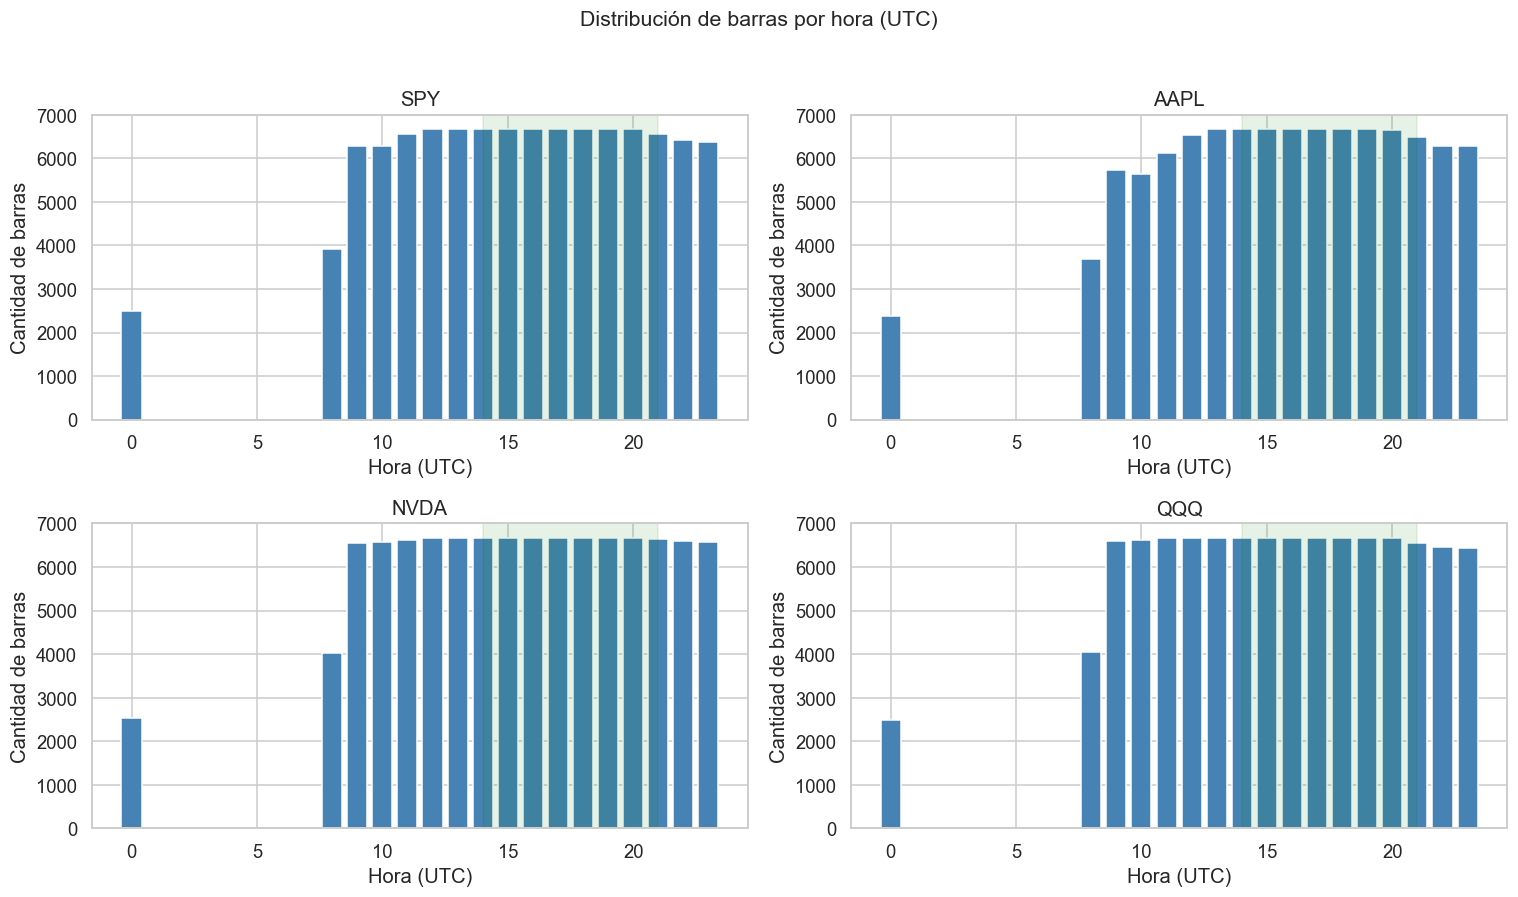

In [41]:
# --- Distribución de barras por hora (UTC) ---
# Alpaca devuelve timestamps en UTC. El mercado US opera 14:30–21:00 UTC (9:30–16:00 ET)
# Si hay barras fuera de este rango → datos pre/post market

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    hours = data[ticker].index.hour
    hour_counts = hours.value_counts().sort_index()
    ax.bar(hour_counts.index, hour_counts.values, color="steelblue", edgecolor="white")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hora (UTC)")
    ax.set_ylabel("Cantidad de barras")
    # Marcar horario de mercado regular (14:30-21:00 UTC)
    ax.axvspan(14, 21, alpha=0.1, color="green", label="Mercado regular")

fig.suptitle("Distribución de barras por hora (UTC)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 1.4 Precios normalizados (base 100)

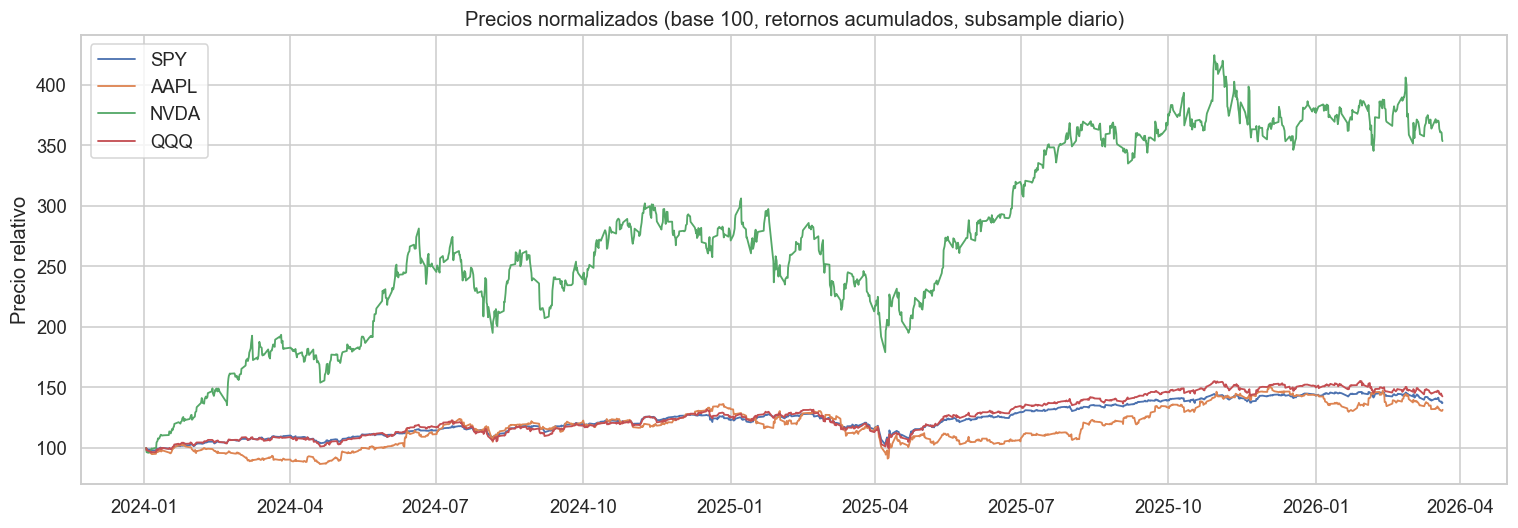

In [26]:
# --- Precios normalizados base 100 ---
# Usamos retornos acumulados en vez de close/close[0] para robustez ante cualquier
# ajuste futuro. Ambos son equivalentes si los precios están bien ajustados.

fig, ax = plt.subplots(figsize=(14, 5))
for ticker, df_t in data.items():
    log_ret = np.log(df_t["close"] / df_t["close"].shift(1)).fillna(0)
    cum_ret = np.exp(log_ret.cumsum()) * 100  # Base 100
    # Subsample cada 78 barras (~1 día) para que el gráfico no sea demasiado pesado
    ax.plot(cum_ret.iloc[::78].index, cum_ret.iloc[::78].values, label=ticker, linewidth=1.2)

ax.set_title("Precios normalizados (base 100, retornos acumulados, subsample diario)")
ax.set_ylabel("Precio relativo")
ax.legend()
fig.tight_layout()
plt.show()

### 1.5 Distribución de retornos de 5-min

A diferencia de retornos diarios, los retornos de 5-min tienen distribuciones con colas aún más pesadas (mayor kurtosis) y están centrados muy cerca de cero.

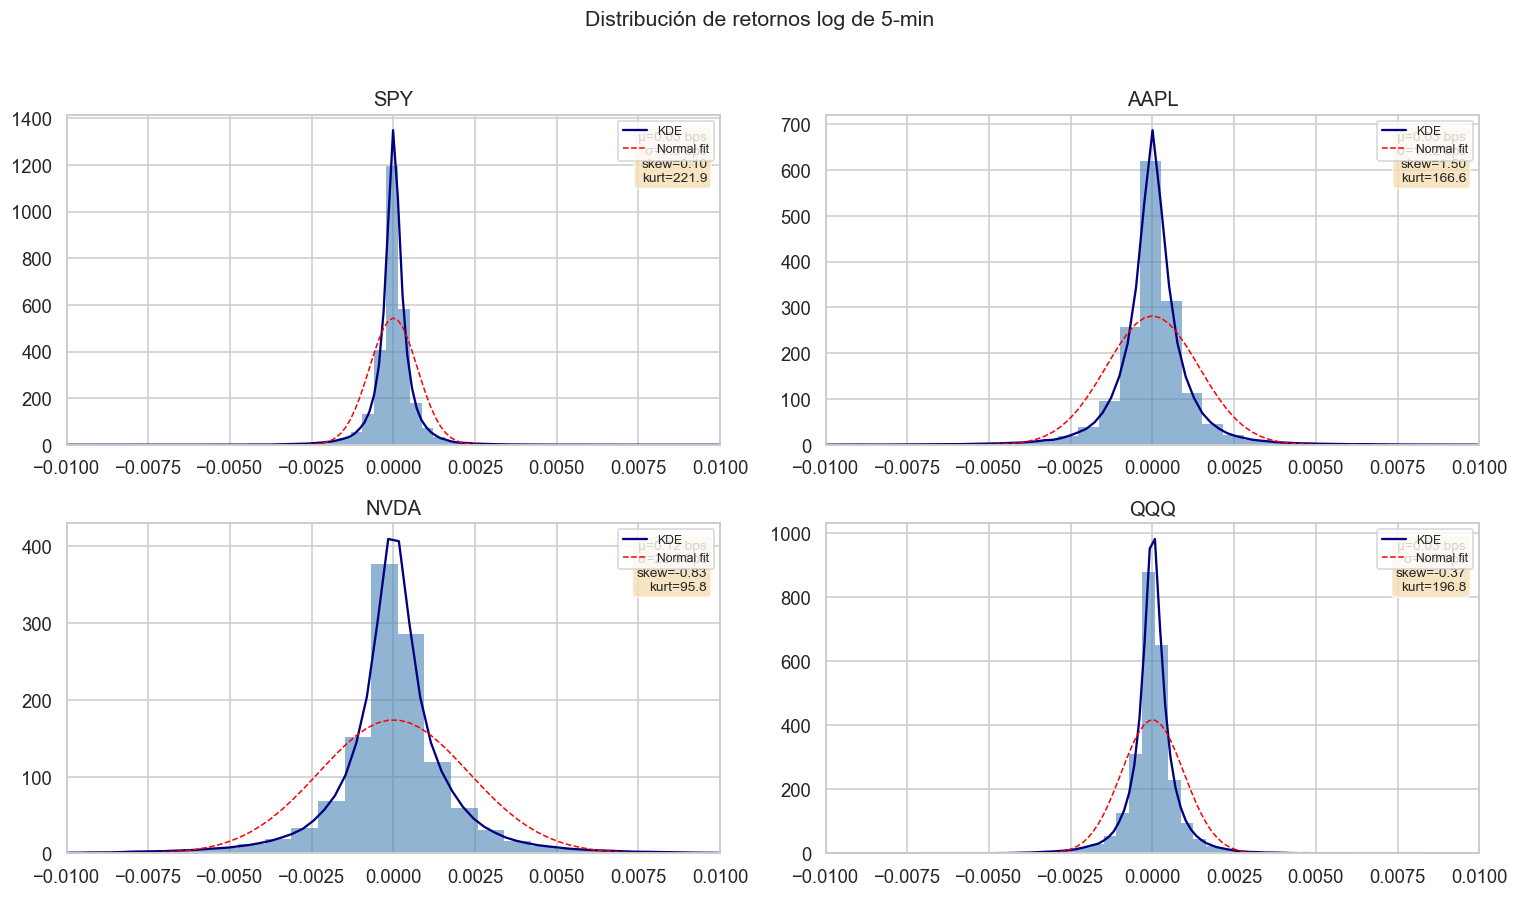

In [27]:
# --- Histogramas de retornos de 5-min con fit normal y estadísticos ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    close = data[ticker]["close"]
    log_ret = np.log(close / close.shift(1)).dropna().values

    # Histograma + KDE
    ax.hist(log_ret, bins=200, density=True, alpha=0.6, color="steelblue", edgecolor="none")
    kde_x = np.linspace(log_ret.min(), log_ret.max(), 500)
    kde = stats.gaussian_kde(log_ret)
    ax.plot(kde_x, kde(kde_x), color="navy", linewidth=1.5, label="KDE")

    # Fit normal para comparación
    mu, sigma = log_ret.mean(), log_ret.std()
    normal_y = stats.norm.pdf(kde_x, mu, sigma)
    ax.plot(kde_x, normal_y, "--", color="red", linewidth=1, label="Normal fit")

    # Estadísticos en el gráfico
    kurt = stats.kurtosis(log_ret, fisher=True)
    skew = stats.skew(log_ret)
    ax.text(0.98, 0.95,
            f"μ={mu*1e4:.2f} bps\nσ={sigma*1e4:.1f} bps\nskew={skew:.2f}\nkurt={kurt:.1f}",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_title(f"{ticker}")
    ax.set_xlim(-0.01, 0.01)  # Zoom a ±1% para ver la forma
    ax.legend(fontsize=8)

fig.suptitle("Distribución de retornos log de 5-min", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
# --- Q-Q Plots (Quantile-Quantile) vs distribución normal ---
# Compara cuantiles observados contra los teóricos de una normal.
# Desviaciones en las colas = distribución de colas pesadas (típico en finanzas).

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, ticker in enumerate(E3_TICKERS):
    ax = axes[i]
    log_ret = np.log(data[ticker]["close"]).diff().dropna()
    stats.probplot(log_ret, dist="norm", plot=ax)
    ax.set_title(f"{ticker}", fontsize=10)
    ax.get_lines()[0].set_markersize(1)  # Puntos pequeños (muchos datos 5-min)

fig.suptitle("Q-Q Plots vs Normal — Retornos 5-min E3", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Distribución de volumen (log-scale)

El volumen de negociación varía enormemente entre tickers (SPY mueve órdenes de magnitud más que AAPL en barras de 5-min). Escala logarítmica permite comparar las distribuciones.

In [ ]:
# --- Boxplot de volumen en escala logarítmica ---
vol_data = []
vol_labels = []
for ticker in E3_TICKERS:
    v = data[ticker]["volume"].replace(0, np.nan).dropna()
    vol_data.append(v.values)
    vol_labels.append(ticker)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(vol_data, labels=vol_labels, patch_artist=True, vert=True)
colors = sns.color_palette("Set2", len(E3_TICKERS))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale("log")
ax.set_ylabel("Volumen (escala log)")
ax.set_title("Distribución de volumen por ticker — barras de 5-min", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Estadísticos de volumen
for ticker in E3_TICKERS:
    v = data[ticker]["volume"]
    print(f"  {ticker}: mediana={v.median():,.0f}  media={v.mean():,.0f}  "
          f"min={v.min():,.0f}  max={v.max():,.0f}  zeros={int((v==0).sum())}")

---

## 2. Estacionalidad intradiaria

Análisis exclusivo de datos de alta frecuencia. En mercados de equities, la microestructura produce patrones reproducibles:
- **Volumen**: forma de "U" (alto en apertura y cierre, bajo al mediodía)
- **Volatilidad**: patrón similar al volumen
- **Retornos medios**: posible efecto de apertura (overnight gap) y cierre

Estos patrones son la razón por la que `build_features.py` incluye `tod_sin`/`tod_cos` como features cíclicos.

### 2.1 Volumen promedio por hora

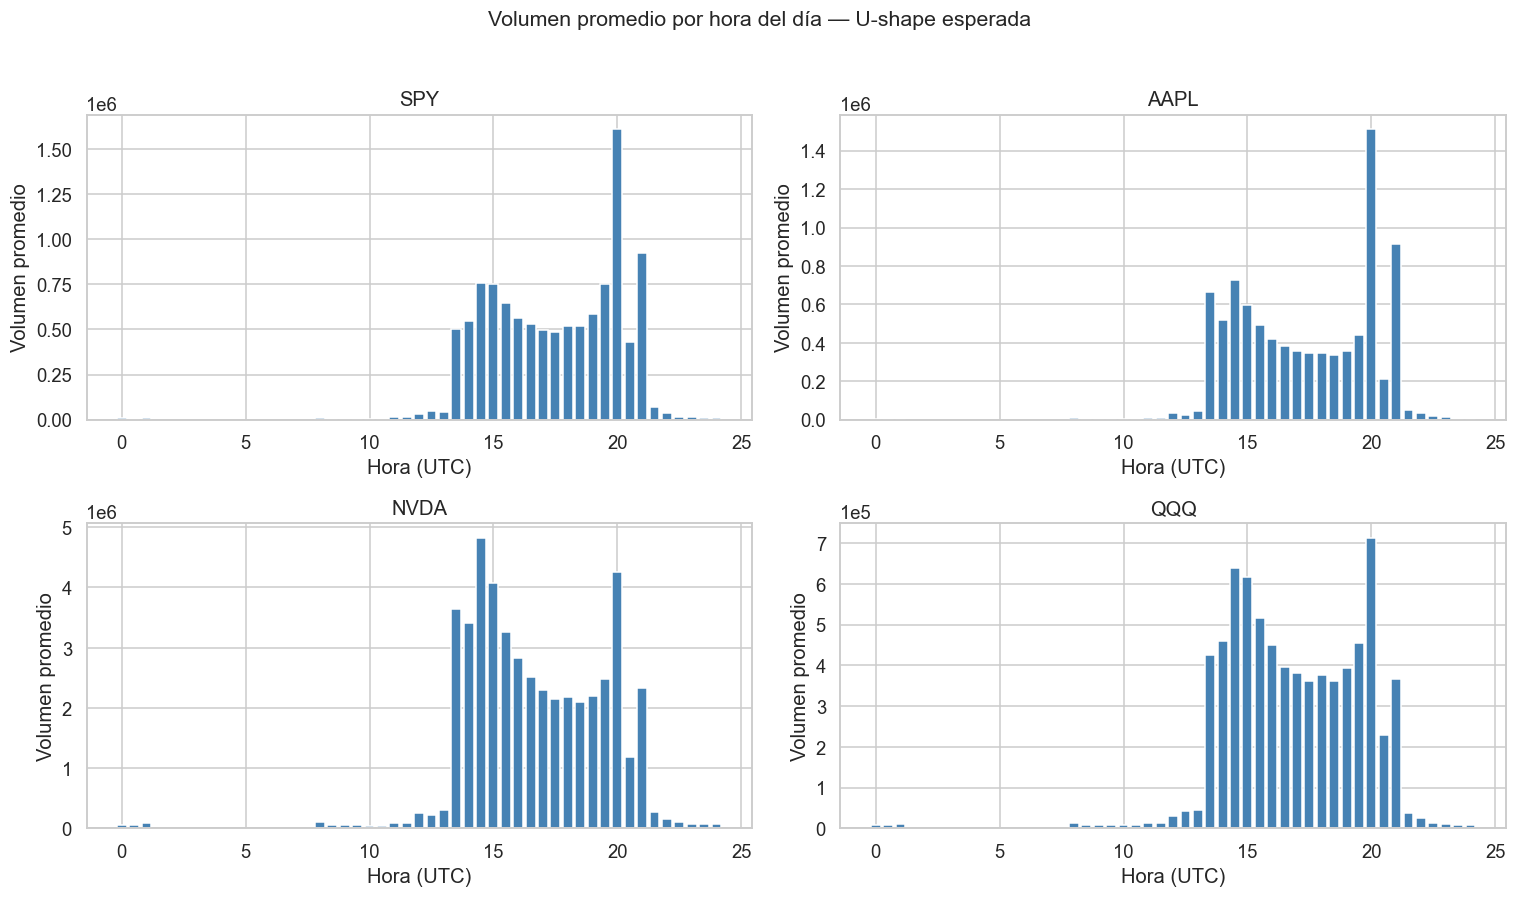

In [28]:
# --- Volumen promedio por hora del día (UTC) ---
# Esperamos la clásica "U-shape": alto al abrir (14:30 UTC) y cerrar (20:55 UTC),
# bajo al mediodía (~17:00 UTC)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["hour"] = df_t.index.hour + df_t.index.minute / 60  # Hora decimal (14.5 = 14:30)

    # Agrupar por hora (bins de 30 min) para suavizar
    df_t["hour_bin"] = (df_t["hour"] * 2).round() / 2  # Redondear a 0.5h
    vol_by_hour = df_t.groupby("hour_bin")["volume"].mean()

    ax.bar(vol_by_hour.index, vol_by_hour.values, width=0.4, color="steelblue", edgecolor="white")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hora (UTC)")
    ax.set_ylabel("Volumen promedio")
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))

fig.suptitle("Volumen promedio por hora del día — U-shape esperada", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 2.2 Volatilidad por hora del día

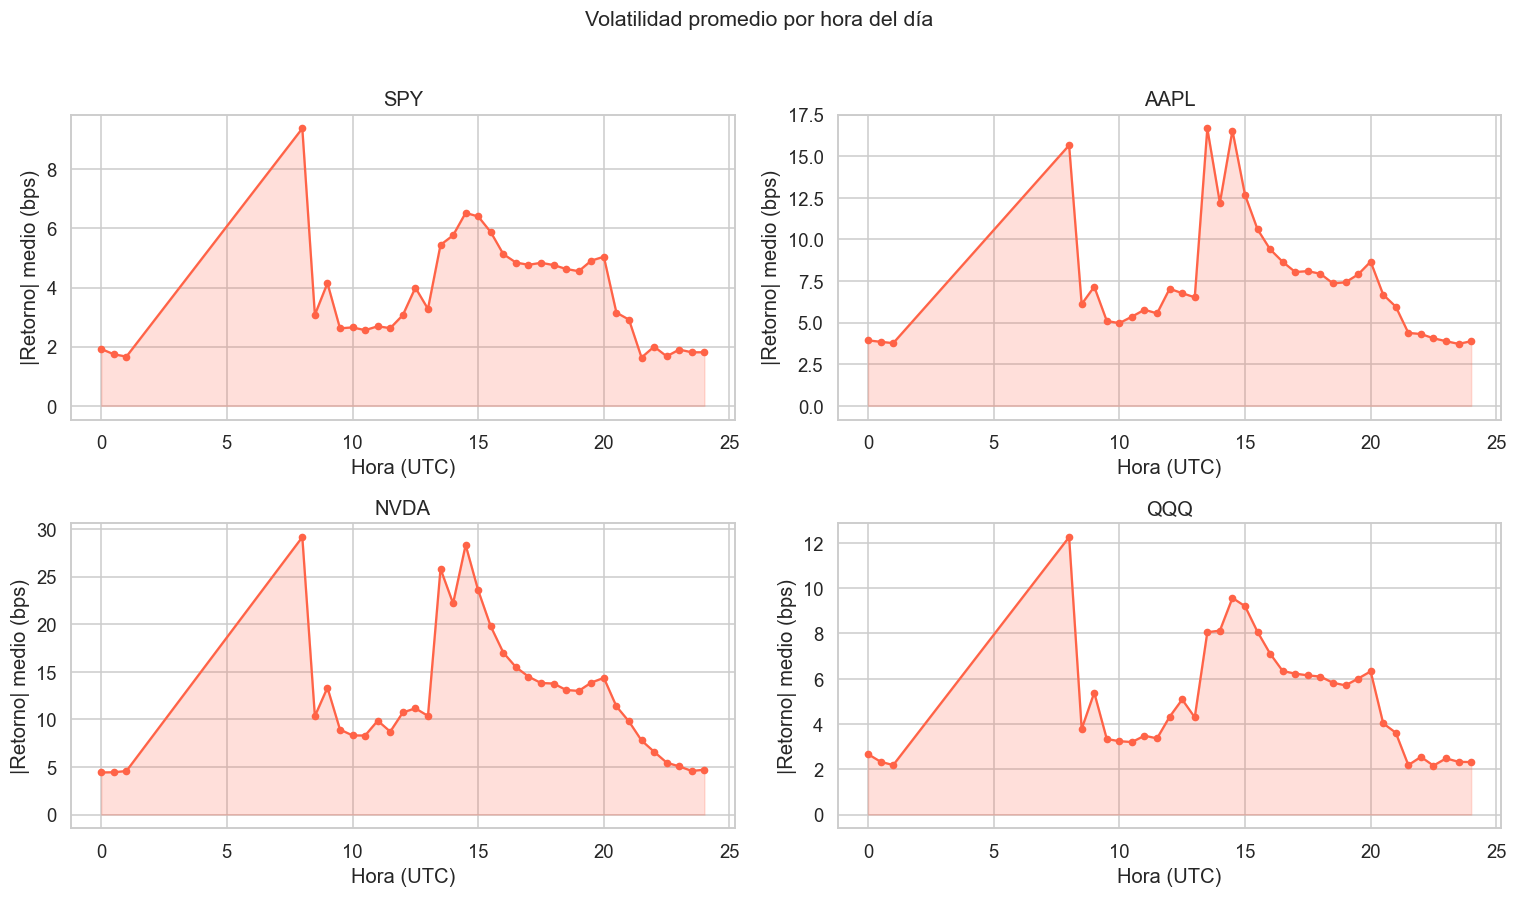

In [29]:
# --- Volatilidad (|retorno|) promedio por hora del día ---
# Patrón esperado: similar al volumen (U-shape).
# Esto importa para el modelo: una señal de +0.05% a las 14:30 UTC (apertura)
# tiene diferente significado que la misma señal a las 17:00 UTC (mediodía tranquilo)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["abs_ret"] = np.abs(np.log(df_t["close"] / df_t["close"].shift(1)))
    df_t["hour_bin"] = ((df_t.index.hour + df_t.index.minute / 60) * 2).round() / 2

    vol_by_hour = df_t.groupby("hour_bin")["abs_ret"].mean() * 1e4  # en bps

    ax.plot(vol_by_hour.index, vol_by_hour.values, "o-", color="tomato", markersize=4)
    ax.fill_between(vol_by_hour.index, vol_by_hour.values, alpha=0.2, color="tomato")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hora (UTC)")
    ax.set_ylabel("|Retorno| medio (bps)")

fig.suptitle("Volatilidad promedio por hora del día", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 2.3 Retorno medio por hora del día

Si el retorno medio varía significativamente por hora, hay una ineficiencia intradiaria explotable (o un artefacto de datos).

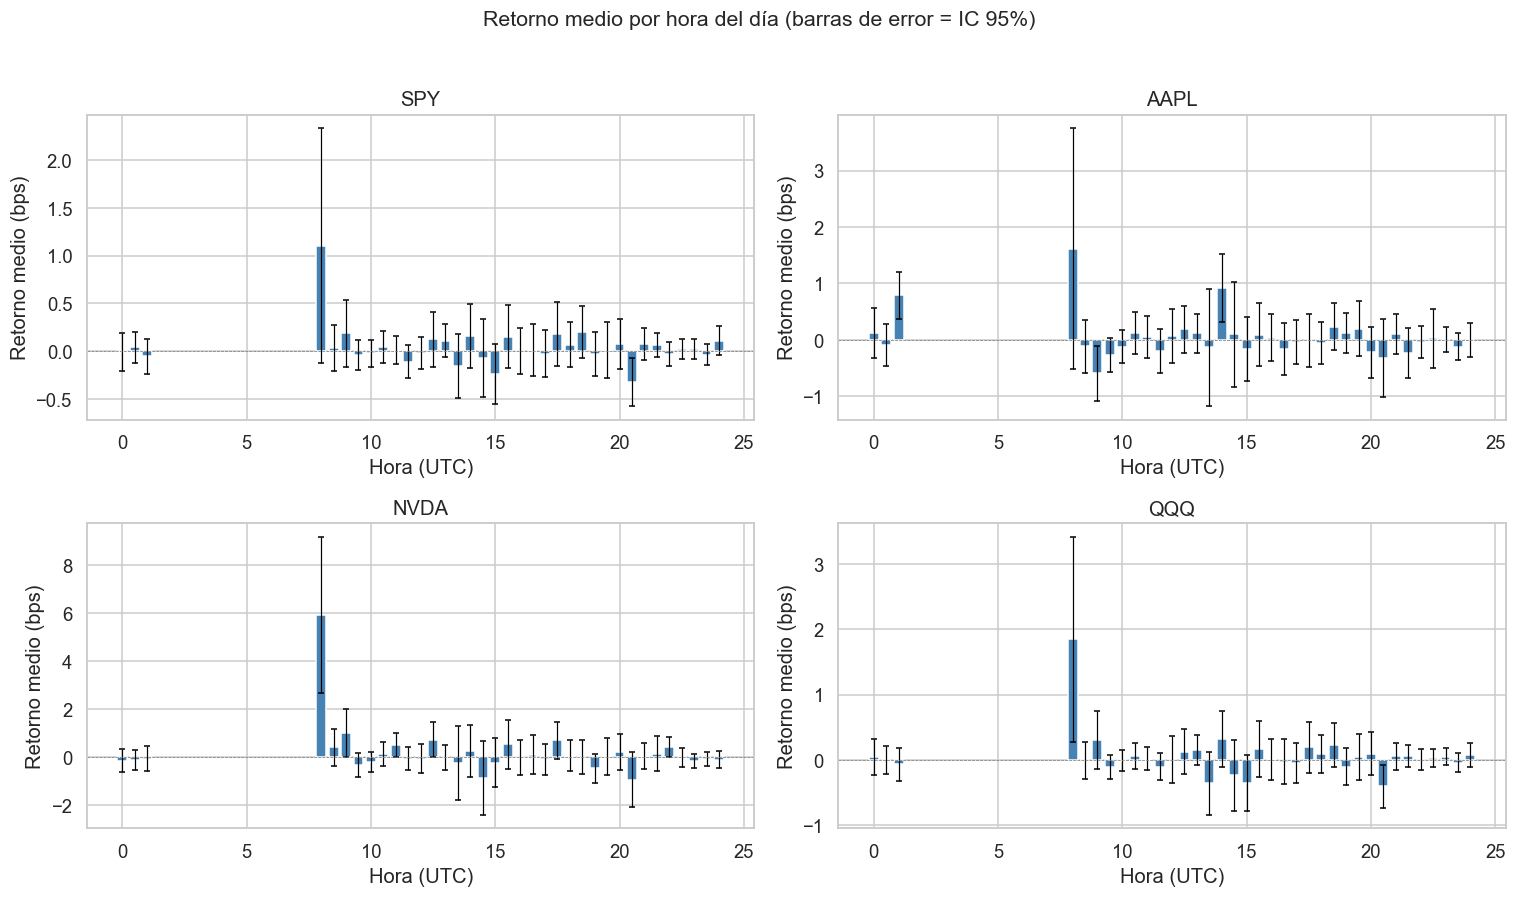

In [30]:
# --- Retorno medio por hora del día (con IC 95%) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["log_ret"] = np.log(df_t["close"] / df_t["close"].shift(1))
    df_t["hour_bin"] = ((df_t.index.hour + df_t.index.minute / 60) * 2).round() / 2

    grouped = df_t.groupby("hour_bin")["log_ret"]
    means = grouped.mean() * 1e4  # bps
    sems = grouped.sem() * 1e4    # standard error of mean, en bps

    ax.bar(means.index, means.values, width=0.4, color="steelblue", edgecolor="white")
    ax.errorbar(means.index, means.values, yerr=1.96 * sems.values,
                fmt="none", color="black", capsize=2, linewidth=0.8)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hora (UTC)")
    ax.set_ylabel("Retorno medio (bps)")

fig.suptitle("Retorno medio por hora del día (barras de error = IC 95%)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---

## 3. Features técnicos

`compute_intraday_features()` calcula 9 indicadores a partir de OHLCV de 5-min:

| Feature | Descripción | Ventana |
|---------|-------------|---------|
| `ret_1` | Retorno log 1-barra | 1 barra |
| `ret_12m` | Momentum 1h (suma ret rolling) | 12 barras |
| `vol_24` | Volatilidad 2h | 24 barras |
| `vol_96` | Volatilidad 1 día | 96 barras |
| `range_pct` | Rango (high-low)/close | 1 barra |
| `atr_14` | ATR proxy normalizado | 14 barras |
| `vol_z_96` | Volume z-score vs media 1 día | 96 barras |
| `tod_sin` | Hora del día (cíclico, seno) | — |
| `tod_cos` | Hora del día (cíclico, coseno) | — |

**Warm-up**: se pierden ~96 barras por ticker (lookback del rolling más largo = `vol_96`).

### 3.1 Computar features y target

In [31]:
# --- Computar features y target para todos los tickers ---
features_all = {}   # {ticker: DataFrame de features}
targets_all = {}    # {ticker: Series de target}
combined_all = {}   # {ticker: features + target, sin NaN}

for ticker, df_t in data.items():
    feats = compute_intraday_features(df_t)
    target = make_target_return(df_t, horizon_bars=HORIZON_BARS)

    # Combinar y eliminar NaN (warm-up de features + horizonte futuro del target)
    combined = pd.concat([feats, target], axis=1).dropna()

    features_all[ticker] = combined[feats.columns]
    targets_all[ticker] = combined[target.name]
    combined_all[ticker] = combined

    n_lost = len(df_t) - len(combined)
    print(
        f"  {ticker}: {len(combined):,} muestras válidas "
        f"({n_lost:,} perdidas por warm-up + horizonte, "
        f"{len(feats.columns)} features)"
    )

  SPY: 104,834 muestras válidas (102 perdidas por warm-up + horizonte, 9 features)
  AAPL: 102,393 muestras válidas (102 perdidas por warm-up + horizonte, 9 features)
  NVDA: 106,081 muestras válidas (102 perdidas por warm-up + horizonte, 9 features)
  QQQ: 105,782 muestras válidas (102 perdidas por warm-up + horizonte, 9 features)


### 3.2 Matriz de correlación features + target

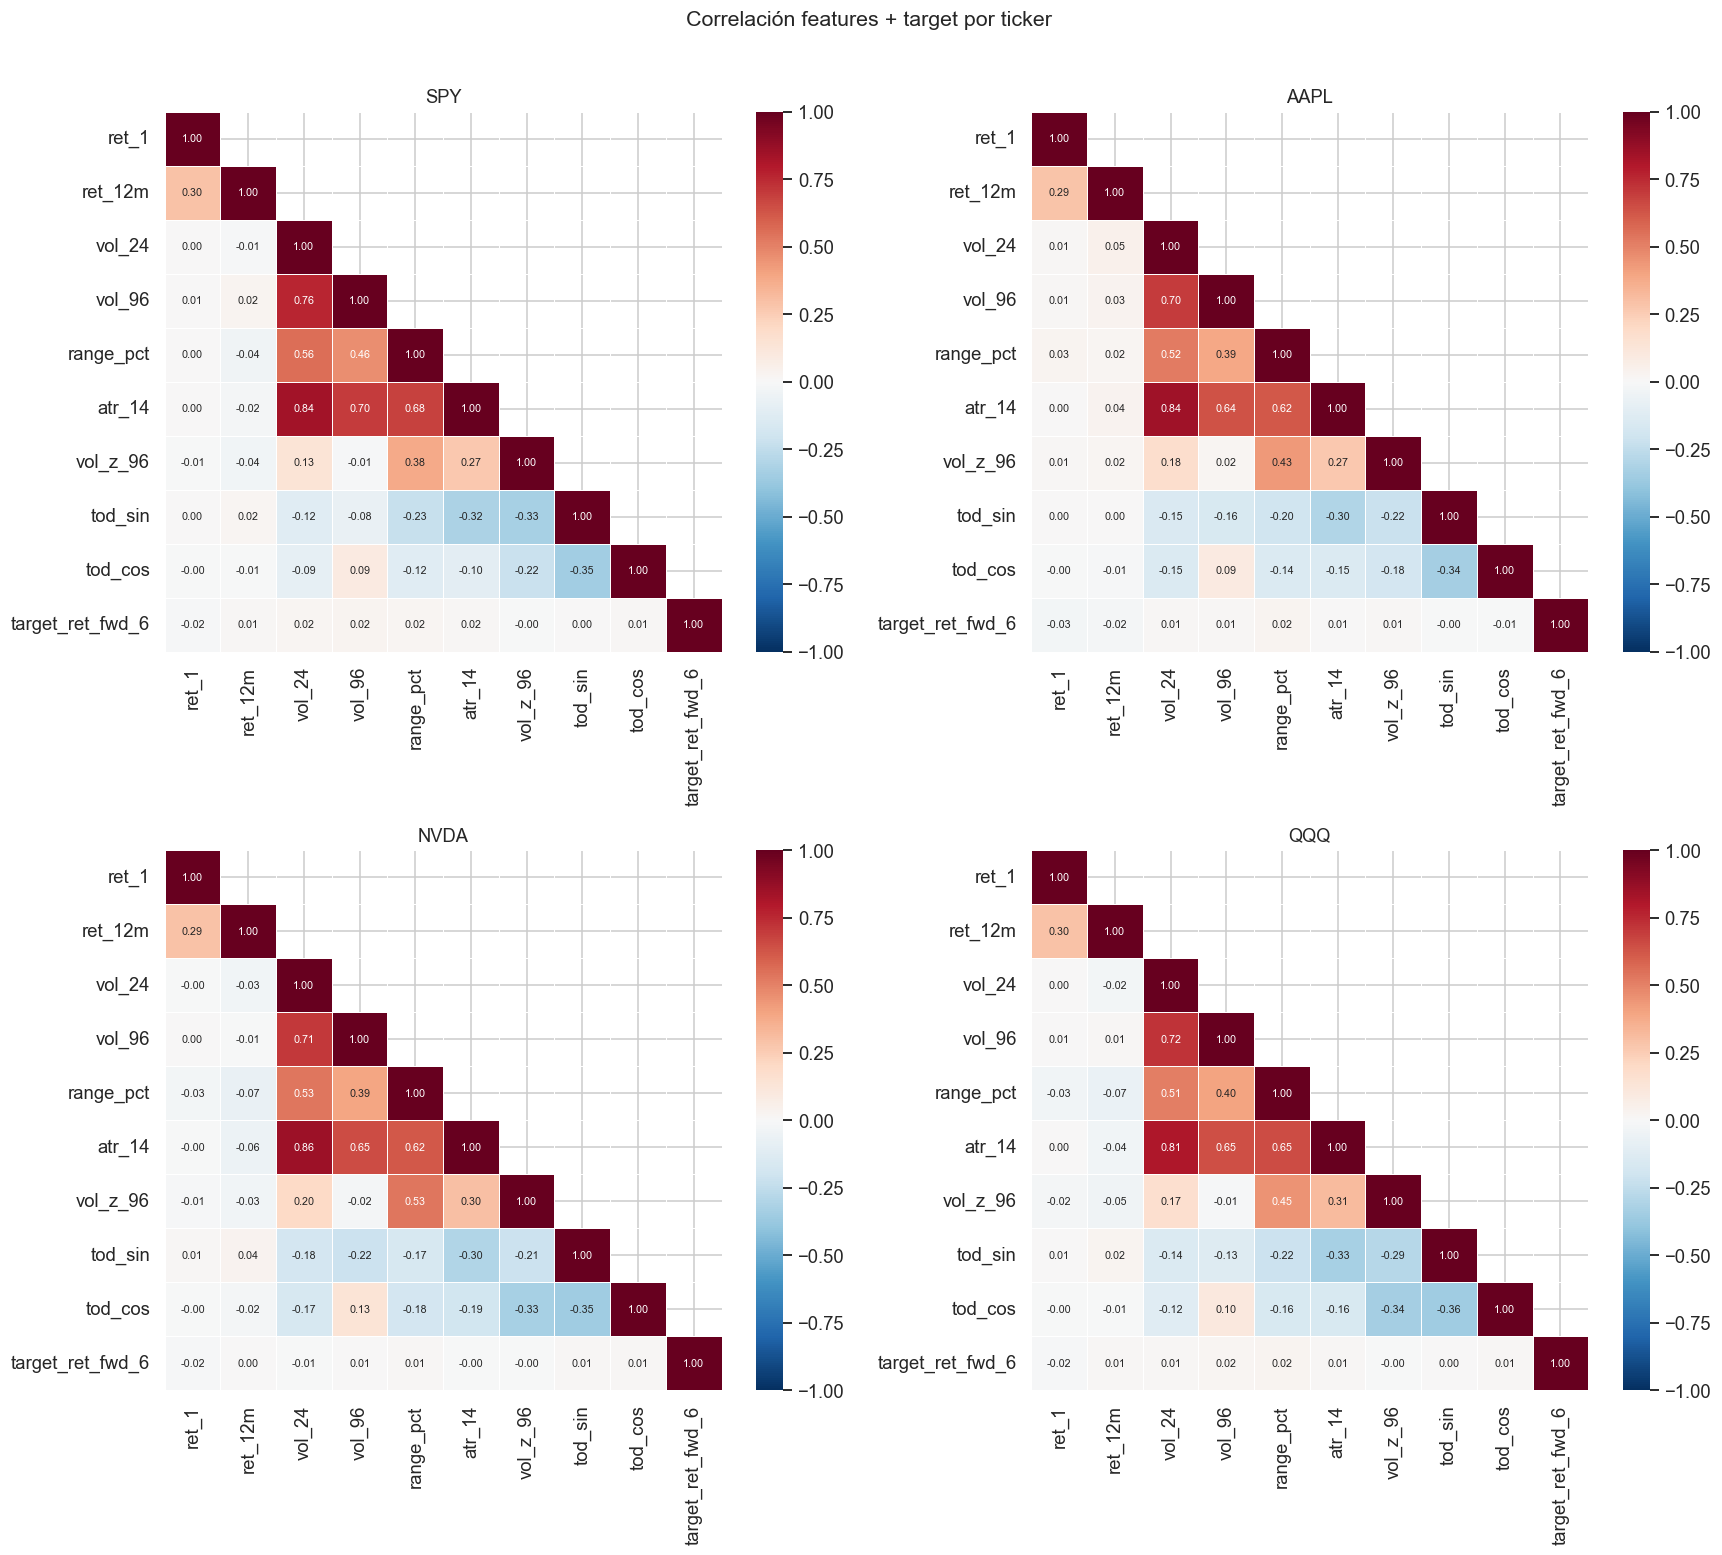

In [32]:
# --- Matriz de correlación entre features + target por ticker ---
# Buscamos:
#   1. Features con correlación alta entre sí (redundancia → potencial para eliminar)
#   2. Features con correlación con el target (señal predictiva)
#   3. Diferencias entre tickers (¿el mismo feature funciona para todos?)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
target_col = f"target_ret_fwd_{HORIZON_BARS}"

for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in combined_all:
        continue
    corr = combined_all[ticker].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, ax=ax,
        annot_kws={"fontsize": 7}, linewidths=0.5,
    )
    ax.set_title(f"{ticker}", fontsize=12)

fig.suptitle("Correlación features + target por ticker", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
# --- Detección automática de multicolinealidad (|r| > 0.7) ---
# Pares de features con correlación alta pueden ser redundantes.
# Revisamos todos los pares para cada ticker y reportamos los que superan el umbral.

MULTICOL_THRESHOLD = 0.7
target_col = f"target_ret_fwd_{HORIZON_BARS}"

print(f"Umbral de multicolinealidad: |r| > {MULTICOL_THRESHOLD}\n")
print("=" * 60)

for ticker in E3_TICKERS:
    if ticker not in combined_all:
        continue
    feat_cols = [c for c in combined_all[ticker].columns if c != target_col]
    corr = combined_all[ticker][feat_cols].corr()

    # Extraer pares únicos con |r| > umbral
    pairs = []
    for i in range(len(feat_cols)):
        for j in range(i + 1, len(feat_cols)):
            r = corr.iloc[i, j]
            if abs(r) > MULTICOL_THRESHOLD:
                pairs.append((feat_cols[i], feat_cols[j], r))

    print(f"\n{ticker}: {len(pairs)} par(es) con |r| > {MULTICOL_THRESHOLD}")
    for f1, f2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:<15} ↔ {f2:<15}  r = {r:+.3f}  {'⚠️' if abs(r) > 0.85 else ''}")

print("\n" + "=" * 60)
print("\nNota: pares con |r| > 0.85 (⚠️) son candidatos fuertes a eliminar uno de los dos.")

### 3.3 Correlación feature-target: comparación cross-ticker

Vista consolidada: para cada feature, ¿cuánto correlaciona con el target en cada ticker?

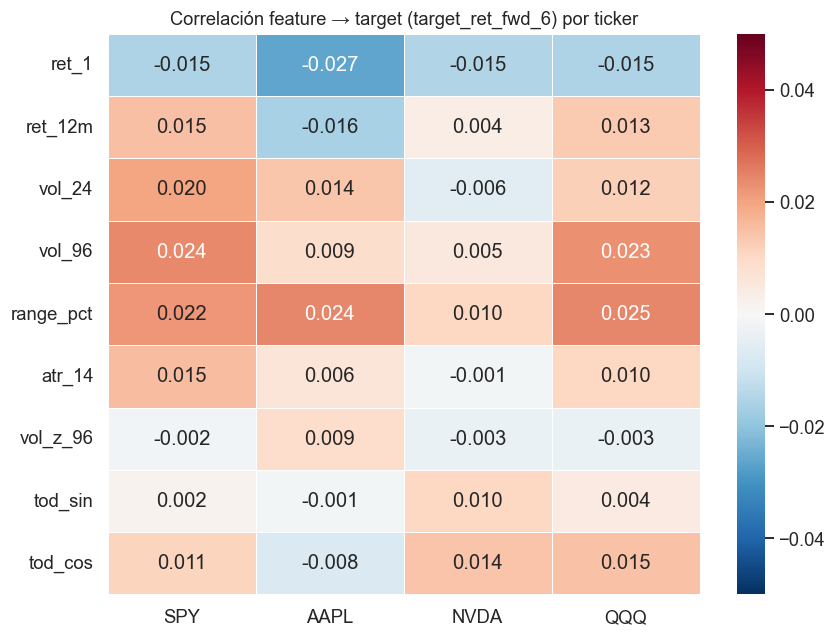


Ranking de features por |correlación| promedio con target:
  range_pct       0.0203
  ret_1           0.0181
  vol_96          0.0152
  vol_24          0.0128
  ret_12m         0.0119
  tod_cos         0.0119
  atr_14          0.0084
  tod_sin         0.0045
  vol_z_96        0.0044


In [33]:
# --- Heatmap de correlación feature-target cross-ticker ---
# Cada celda = correlación de un feature con el target para un ticker
# Esto revela qué features tienen señal consistente vs. ticker-específica

target_col = f"target_ret_fwd_{HORIZON_BARS}"
feat_cols = list(features_all[E3_TICKERS[0]].columns)

corr_matrix = pd.DataFrame(index=feat_cols, columns=E3_TICKERS, dtype=float)
for ticker in E3_TICKERS:
    if ticker not in combined_all:
        continue
    for feat in feat_cols:
        corr_matrix.loc[feat, ticker] = combined_all[ticker][feat].corr(combined_all[ticker][target_col])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix.astype(float), annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-0.05, vmax=0.05, ax=ax,
    linewidths=0.5,
)
ax.set_title(f"Correlación feature → target ({target_col}) por ticker", fontsize=12)
fig.tight_layout()
plt.show()

# Ranking: features con mayor |correlación| promedio
avg_abs_corr = corr_matrix.astype(float).abs().mean(axis=1).sort_values(ascending=False)
print("\nRanking de features por |correlación| promedio con target:")
for feat, val in avg_abs_corr.items():
    print(f"  {feat:<15} {val:.4f}")

### 3.4 Feature vs Target (scatter + regresión)

Scatter plots de cada feature contra el target, con línea de regresión, coeficiente de Pearson r y p-value. Para datasets intradiarios con ~100K puntos, subsampleamos para visualización pero calculamos estadísticos sobre el dataset completo.

In [ ]:
# --- Scatter plots: feature vs target con Pearson r + p-value ---
# Pool de todos los tickers para ver la relación global.
# Subsample para visualización (5K puntos), estadísticos sobre datos completos.

target_col = f"target_ret_fwd_{HORIZON_BARS}"
pool = pd.concat([combined_all[t] for t in E3_TICKERS if t in combined_all], ignore_index=True)
feat_cols = list(features_all[E3_TICKERS[0]].columns)

n_feats = len(feat_cols)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

SUBSAMPLE = 5000
rng = np.random.RandomState(42)
idx_plot = rng.choice(len(pool), size=min(SUBSAMPLE, len(pool)), replace=False)

for i, feat in enumerate(feat_cols):
    ax = axes[i]
    x_full = pool[feat].dropna()
    y_full = pool.loc[x_full.index, target_col].dropna()
    common = x_full.index.intersection(y_full.index)

    # Pearson sobre datos completos
    r, p = stats.pearsonr(pool.loc[common, feat], pool.loc[common, target_col])

    # Scatter subsampleado
    x_plot = pool[feat].iloc[idx_plot]
    y_plot = pool[target_col].iloc[idx_plot]
    ax.scatter(x_plot, y_plot, alpha=0.08, s=4, color="steelblue")

    # Línea de regresión sobre datos completos
    z = np.polyfit(pool.loc[common, feat], pool.loc[common, target_col], 1)
    x_line = np.linspace(x_plot.quantile(0.01), x_plot.quantile(0.99), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=1.5)

    ax.set_title(f"{feat}\nr={r:.4f}  p={p:.2e}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("target" if i % n_cols == 0 else "")

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature vs Target (pool de todos los tickers) — E3", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

---

## 4. Análisis del target (retorno forward 30 min)

El target es `ln(close[t+6] / close[t])` — el retorno logarítmico a 6 barras (30 min).

A diferencia de E1 (90 días), este target opera en escala ~100× más pequeña.
La pregunta clave: ¿hay suficiente señal sobre el ruido para que el LSTM la capture?

### 4.1 Distribución del target por ticker

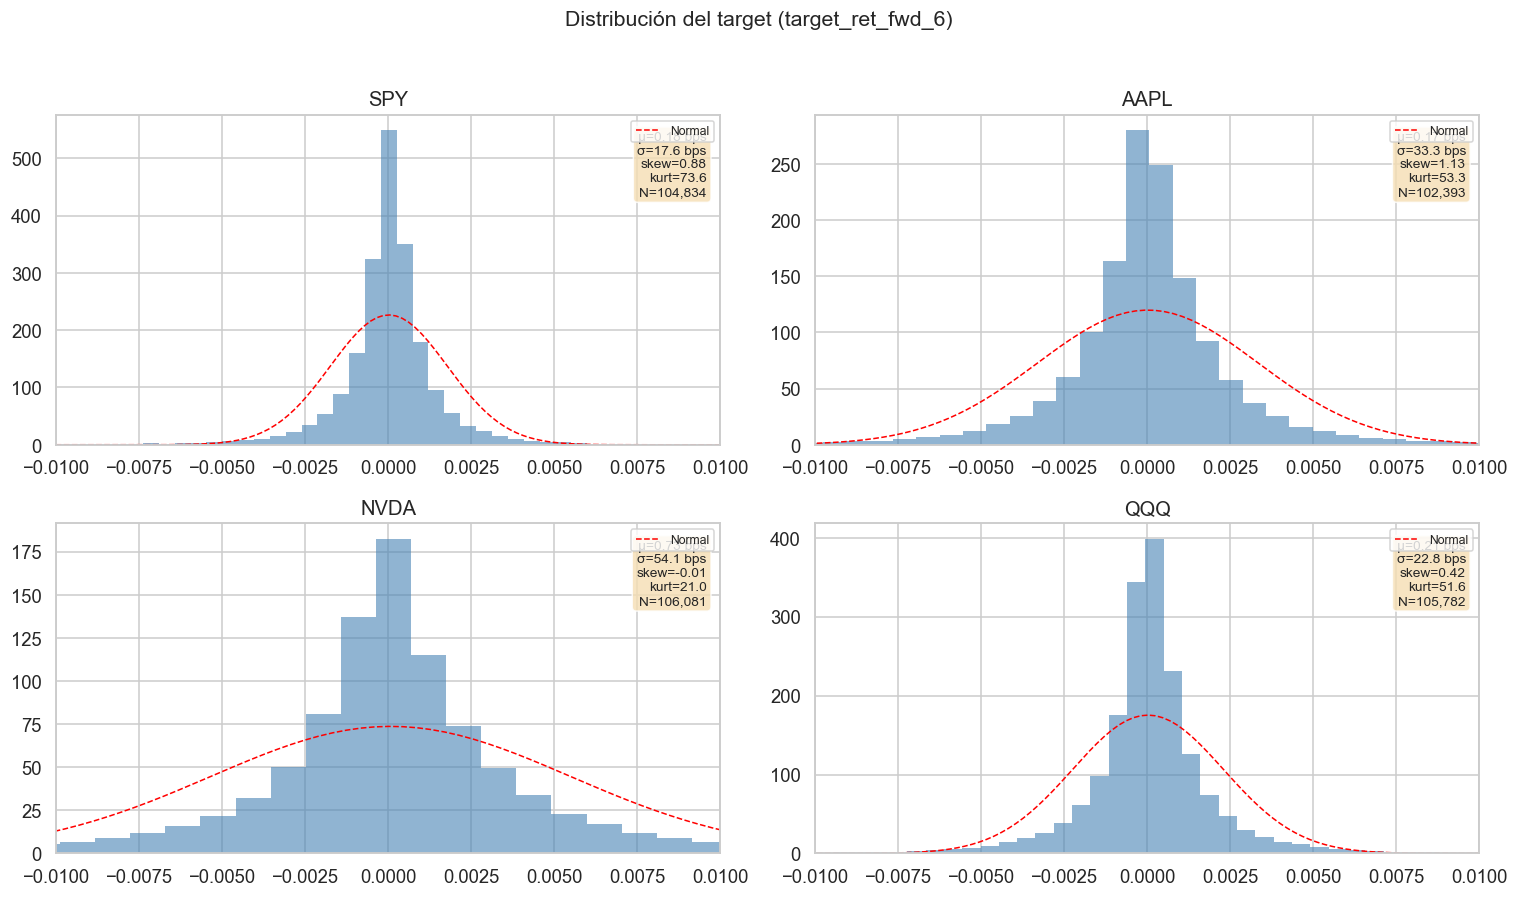

In [34]:
# --- Distribución del target (retorno forward 30 min) por ticker ---
target_col = f"target_ret_fwd_{HORIZON_BARS}"

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in targets_all:
        continue
    y = targets_all[ticker].values

    ax.hist(y, bins=200, density=True, alpha=0.6, color="steelblue", edgecolor="none")

    # Fit normal
    mu, sigma = y.mean(), y.std()
    x_range = np.linspace(y.min(), y.max(), 500)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), "--", color="red", linewidth=1, label="Normal")

    kurt = stats.kurtosis(y, fisher=True)
    skew_ = stats.skew(y)
    ax.text(0.98, 0.95,
            f"μ={mu*1e4:.2f} bps\nσ={sigma*1e4:.1f} bps\nskew={skew_:.2f}\nkurt={kurt:.1f}\nN={len(y):,}",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_title(f"{ticker}")
    ax.set_xlim(-0.01, 0.01)
    ax.legend(fontsize=8)

fig.suptitle(f"Distribución del target ({target_col})", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 4.2 Autocorrelación del target (ACF)

La autocorrelación del target es crítica: si ACF decae rápido, cada muestra es casi independiente y el LSTM tiene poco que "recordar". Si persiste, hay patrones temporales explotables.

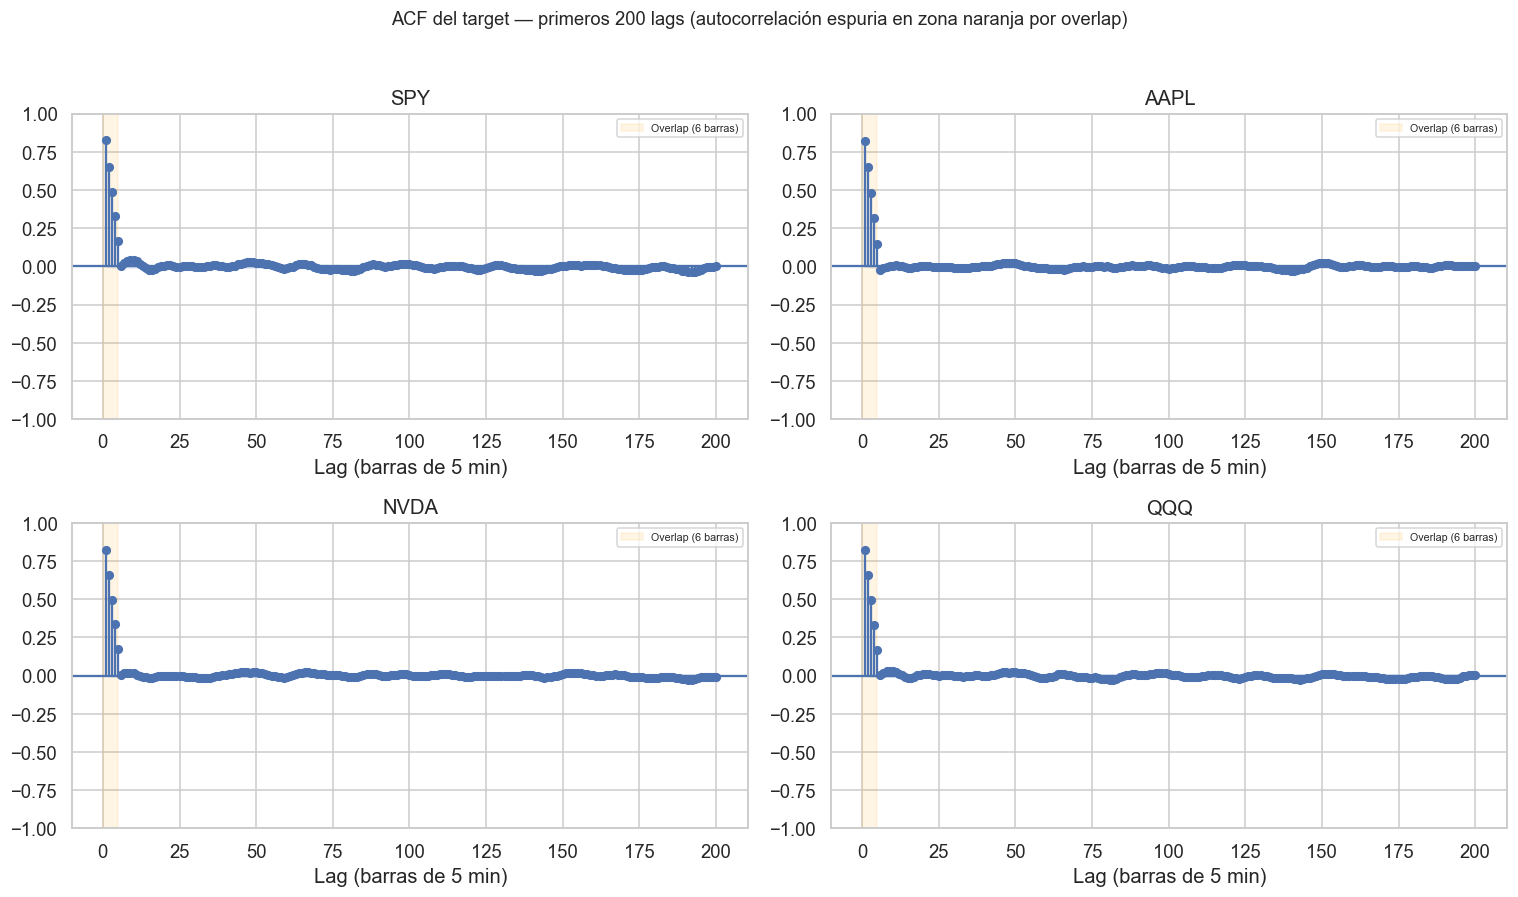

In [35]:
# --- ACF del target (retorno forward 30 min) ---
# Mostramos hasta 200 lags (~16 horas ≈ 2 días de trading)
# Nota: el target usa retornos solapados (horizon=6 barras), por lo que
# los primeros ~5 lags tendrán autocorrelación espuria por overlap

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in targets_all:
        continue
    plot_acf(targets_all[ticker].values, lags=200, ax=ax, alpha=0.05,
             title=f"{ticker}", zero=False)
    ax.set_xlabel("Lag (barras de 5 min)")
    # Marcar zona de overlap esperada
    ax.axvspan(0, HORIZON_BARS - 1, alpha=0.1, color="orange", label=f"Overlap ({HORIZON_BARS} barras)")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("ACF del target — primeros 200 lags (autocorrelación espuria en zona naranja por overlap)",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

### 4.3 Rolling mean y std del target

Permite detectar regímenes de volatilidad y cambios de régimen en el target a lo largo del tiempo.

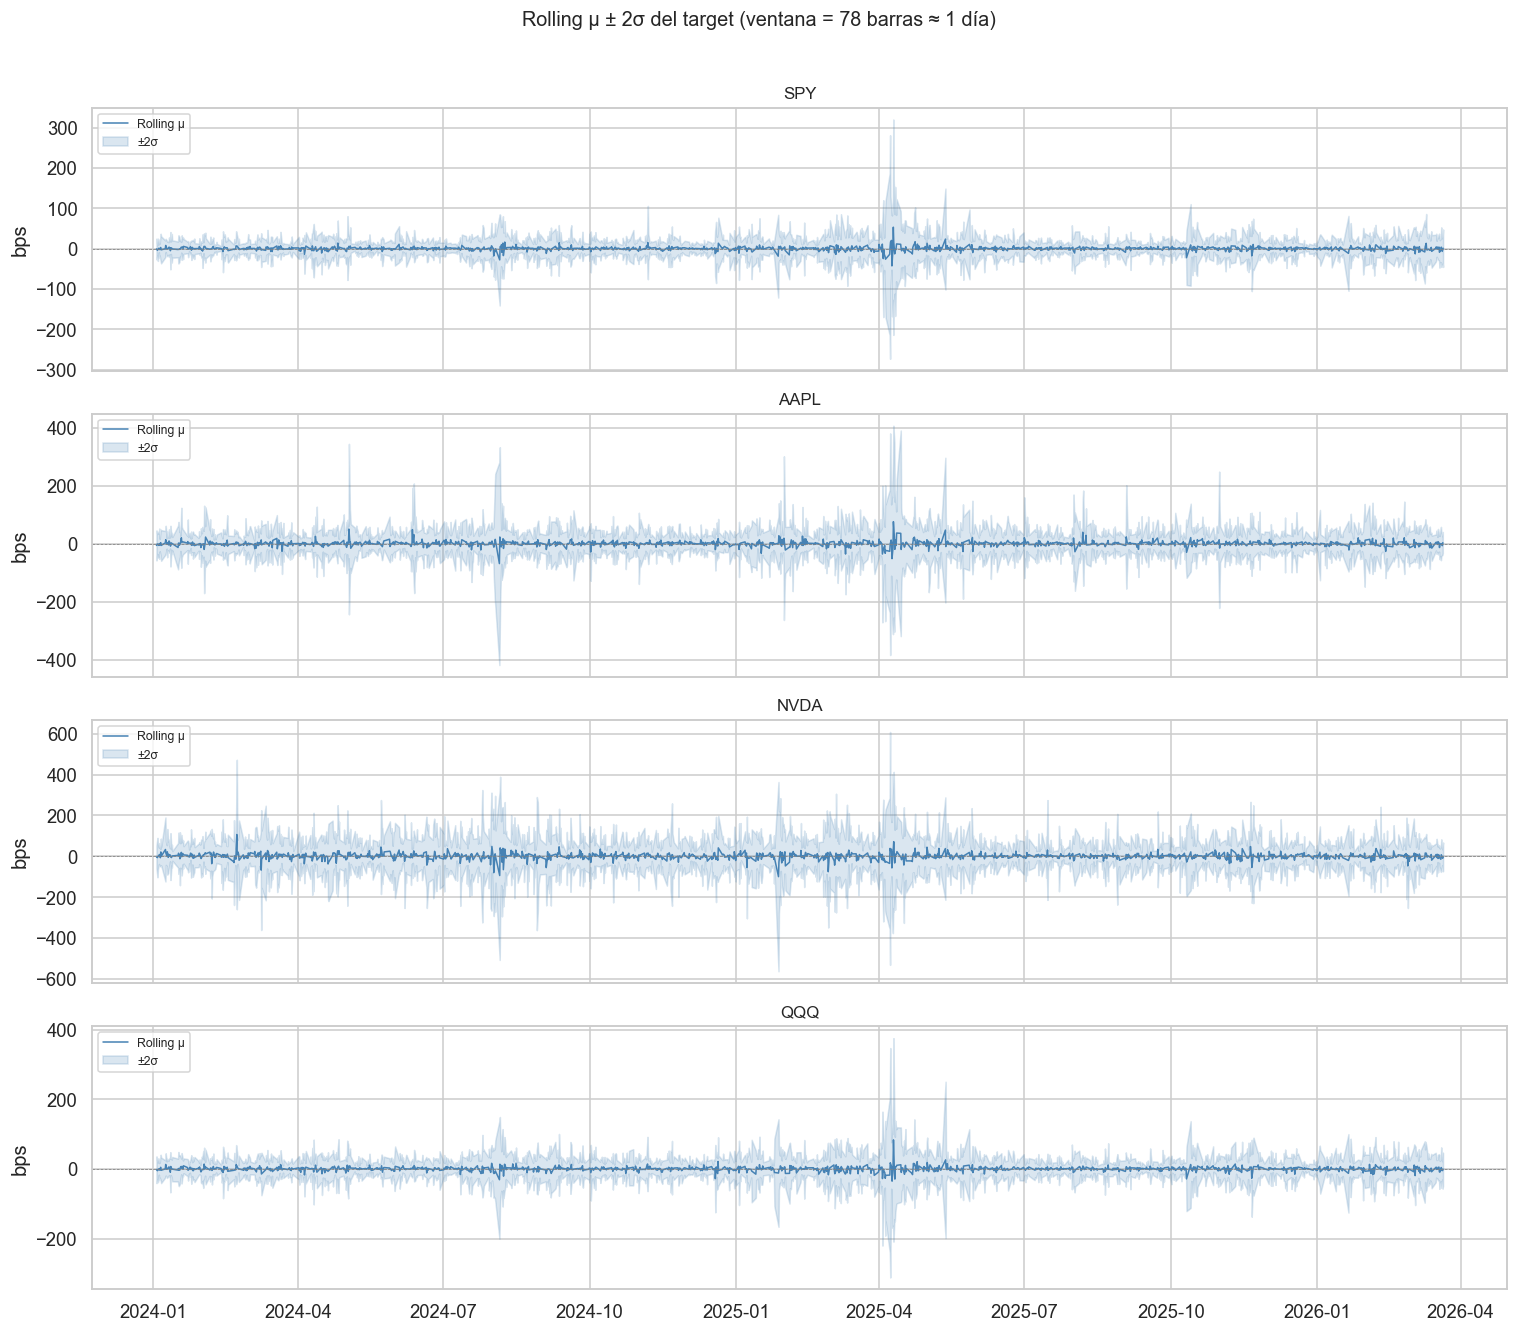

In [36]:
# --- Rolling mean y std del target (ventana = 1 día = 78 barras) ---
# Subsampleamos a resolución diaria para que el gráfico sea legible
ROLL_WINDOW = BARS_PER_TRADING_DAY  # 78 barras = 1 día

fig, axes = plt.subplots(len(E3_TICKERS), 1, figsize=(14, 3 * len(E3_TICKERS)), sharex=True)
if len(E3_TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, E3_TICKERS):
    if ticker not in targets_all:
        continue
    y = targets_all[ticker]
    roll_mean = y.rolling(ROLL_WINDOW).mean().iloc[::ROLL_WINDOW]   # subsample diario
    roll_std = y.rolling(ROLL_WINDOW).std().iloc[::ROLL_WINDOW]

    ax.plot(roll_mean.index, roll_mean.values * 1e4, color="steelblue", linewidth=1, label="Rolling μ")
    ax.fill_between(
        roll_std.index,
        (roll_mean.values - 2 * roll_std.values) * 1e4,
        (roll_mean.values + 2 * roll_std.values) * 1e4,
        alpha=0.2, color="steelblue", label="±2σ",
    )
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_ylabel("bps")
    ax.set_title(f"{ticker}", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Rolling μ ± 2σ del target (ventana = {ROLL_WINDOW} barras ≈ 1 día)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

---

## 5. Señal vs. ruido y viabilidad de trading

### 5.1 ¿Qué fracción del target supera el costo de transacción?

El costo round-trip es 20 bps. Para que una predicción sea rentable, el retorno predicho debe superar este umbral. ¿Qué fracción del target lo hace?

In [37]:
# --- Fracción del target que supera el costo de transacción ---
# Si solo el 5% de las barras tienen |target| > 20 bps, el modelo necesita
# ser muy selectivo (operar poco) para ser rentable

cost_threshold = ROUND_TRIP_BPS / 1e4  # 20 bps → 0.002

print(f"Costo round-trip: {ROUND_TRIP_BPS} bps ({cost_threshold:.4f})")
print(f"{'Ticker':<10} {'|target|>costo':>15} {'target>+costo':>15} {'target<-costo':>15} {'|target| μ (bps)':>15}")
print("-" * 75)

for ticker in E3_TICKERS:
    if ticker not in targets_all:
        continue
    y = targets_all[ticker].values
    frac_exceeds = np.mean(np.abs(y) > cost_threshold)
    frac_long = np.mean(y > cost_threshold)
    frac_short = np.mean(y < -cost_threshold)
    mean_abs = np.mean(np.abs(y)) * 1e4

    print(f"{ticker:<10} {frac_exceeds:>14.1%} {frac_long:>14.1%} {frac_short:>14.1%} {mean_abs:>14.1f}")

print(f"\n→ El modelo debe ser selectivo: operar solo cuando la señal es fuerte.")

Costo round-trip: 20 bps (0.0020)
Ticker      |target|>costo   target>+costo   target<-costo |target| μ (bps)
---------------------------------------------------------------------------
SPY                 12.5%           6.2%           6.4%            9.9
AAPL                29.0%          14.7%          14.3%           18.7
NVDA                46.7%          24.5%          22.3%           32.2
QQQ                 19.2%           9.7%           9.5%           13.1

→ El modelo debe ser selectivo: operar solo cuando la señal es fuerte.


### 5.2 Distribución del target por hora del día

¿La "señal explotable" se concentra en ciertas horas? Si el target es más volátil al abrir, el modelo podría aprender a operar más en esas horas.

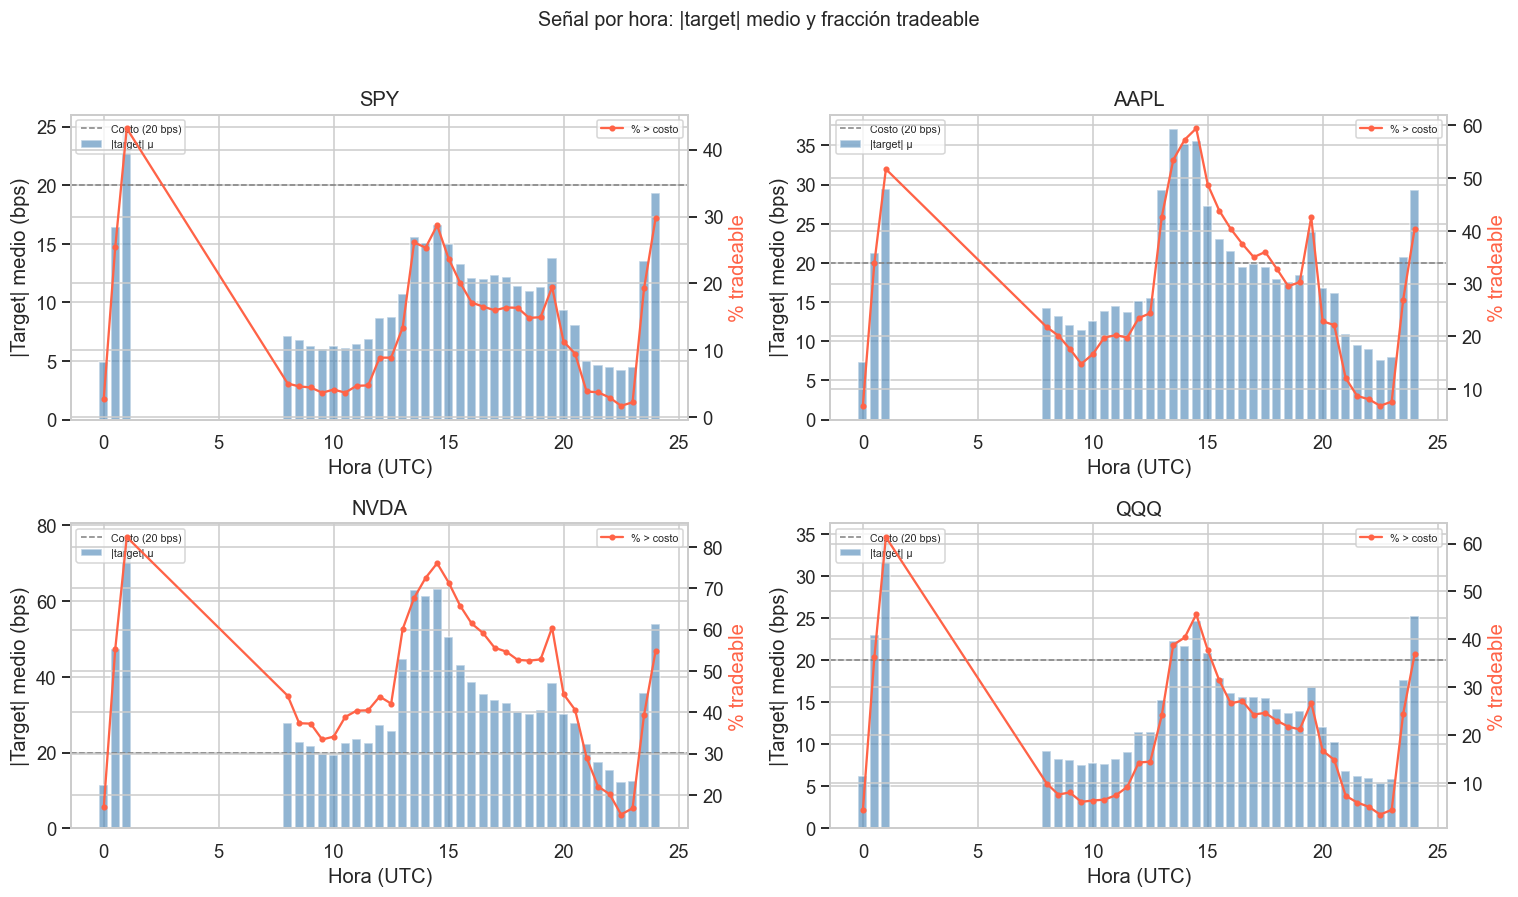

In [38]:
# --- |Target| promedio y % que supera costo, por hora del día ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in combined_all:
        continue
    df_c = combined_all[ticker].copy()
    target_col = f"target_ret_fwd_{HORIZON_BARS}"
    df_c["abs_target_bps"] = df_c[target_col].abs() * 1e4
    df_c["hour_bin"] = ((df_c.index.hour + df_c.index.minute / 60) * 2).round() / 2

    hourly = df_c.groupby("hour_bin").agg(
        mean_abs=("abs_target_bps", "mean"),
        frac_tradeable=("abs_target_bps", lambda x: (x > ROUND_TRIP_BPS).mean()),
    )

    ax2 = ax.twinx()
    ax.bar(hourly.index, hourly["mean_abs"], width=0.4, color="steelblue", alpha=0.6, label="|target| μ")
    ax2.plot(hourly.index, hourly["frac_tradeable"] * 100, "o-", color="tomato", markersize=3, label="% > costo")
    ax.axhline(ROUND_TRIP_BPS, color="gray", linewidth=1, linestyle="--", label=f"Costo ({ROUND_TRIP_BPS} bps)")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hora (UTC)")
    ax.set_ylabel("|Target| medio (bps)")
    ax2.set_ylabel("% tradeable", color="tomato")
    ax.legend(fontsize=7, loc="upper left")
    ax2.legend(fontsize=7, loc="upper right")

fig.suptitle("Señal por hora: |target| medio y fracción tradeable", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---

## 6. Tabla resumen de estadísticos

In [39]:
# --- Tabla resumen por ticker: retornos, target, features ---
target_col = f"target_ret_fwd_{HORIZON_BARS}"
cost_threshold = ROUND_TRIP_BPS / 1e4

rows = []
for ticker in E3_TICKERS:
    if ticker not in data:
        continue
    df_t = data[ticker]
    close = df_t["close"]
    ret = np.log(close / close.shift(1)).dropna()
    y = targets_all[ticker].values

    rows.append({
        "Ticker": ticker,
        "Barras": f"{len(df_t):,}",
        "Muestras válidas": f"{len(targets_all[ticker]):,}",
        "Ret 5m μ (bps)": f"{ret.mean() * 1e4:.3f}",
        "Ret 5m σ (bps)": f"{ret.std() * 1e4:.1f}",
        "Ret 5m kurt": f"{stats.kurtosis(ret, fisher=True):.1f}",
        "Target μ (bps)": f"{y.mean() * 1e4:.3f}",
        "Target σ (bps)": f"{y.std() * 1e4:.1f}",
        "Target kurt": f"{stats.kurtosis(y, fisher=True):.1f}",
        f"|Target|>{ROUND_TRIP_BPS}bps": f"{np.mean(np.abs(y) > cost_threshold):.1%}",
    })

stats_df = pd.DataFrame(rows)
stats_df.style.set_caption("Estadísticos resumen por ticker — E3 Intraday")

,Ticker,Barras,Muestras válidas,Ret 5m μ (bps),Ret 5m σ (bps),Ret 5m kurt,Target μ (bps),Target σ (bps),Target kurt,|Target|>20bps
0,SPY,"104,936","104,834",0.030,7.3,221.9,0.185,17.6,73.6,12.5%
1,AAPL,"102,495","102,393",0.027,14.2,166.6,0.170,33.3,53.3,29.0%
2,NVDA,"106,183","106,081",0.119,22.9,95.8,0.730,54.1,21.0,46.7%
3,QQQ,"105,884","105,782",0.034,9.6,196.8,0.212,22.8,51.6,19.2%


### 6.1 Heatmap cross-ticker: media de cada feature

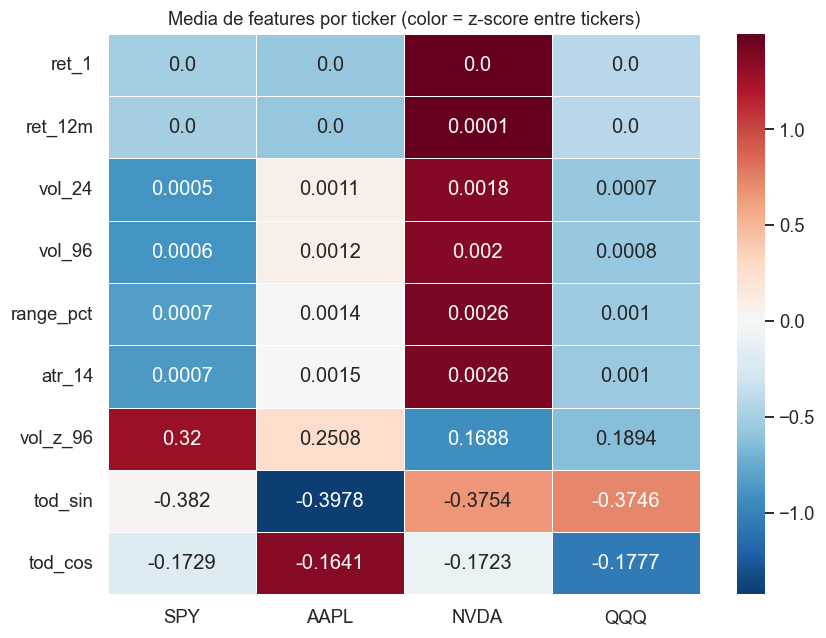

In [40]:
# --- Heatmap cross-ticker: media de cada feature ---
# Revela diferencias estructurales entre tickers (ej: NVDA más volátil)
feat_cols = list(features_all[E3_TICKERS[0]].columns)

mean_matrix = pd.DataFrame(index=feat_cols, columns=E3_TICKERS, dtype=float)
for ticker in E3_TICKERS:
    if ticker not in features_all:
        continue
    for feat in feat_cols:
        mean_matrix.loc[feat, ticker] = features_all[ticker][feat].mean()

fig, ax = plt.subplots(figsize=(8, 6))
# Normalizar por feature (z-score por fila) para que sean comparables
mean_z = mean_matrix.astype(float).apply(lambda row: (row - row.mean()) / (row.std() + 1e-12), axis=1)
sns.heatmap(mean_z, annot=mean_matrix.astype(float).round(4), fmt="", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Media de features por ticker (color = z-score entre tickers)", fontsize=12)
fig.tight_layout()
plt.show()

---
## 7. Conclusiones del EDA

### 7.1 Distribuciones no normales y colas pesadas

1. **Retornos de 5-min fuertemente no-normales**
   - Los Q-Q plots y tests de Jarque-Bera rechazan normalidad en todos los tickers. La kurtosis es incluso mayor que en datos diarios (E1/E2).
   - Esto refuerza la elección de Huber loss y un modelo no lineal (LSTM) capaz de capturar relaciones no lineales.

2. **Concentración extrema cerca de cero**
   - La gran mayoría de los retornos de 5-min están dentro de ±5 bps, lo cual establece un piso mínimo de señal para que el modelo sea rentable.

### 7.2 Estacionalidad intradiaria

1. **Patrón U-shape en volumen y volatilidad**
   - Alta actividad en apertura (13:30-14:30 UTC) y cierre (19:00-20:00 UTC), con mínimo al mediodía.
   - Los features cíclicos `tod_sin`/`tod_cos` capturan esta estructura temporal.

2. **Retorno medio por hora no es significativamente distinto de cero**
   - No hay una "hora dorada" consistente para operar — la señal explotable debe venir de los features técnicos, no del horario.

### 7.3 Features y multicolinealidad

1. **9 features técnicos diseñados para alta frecuencia**
   - `vol_24` y `vol_96` capturan volatilidad a dos escalas; `atr_14` aporta rango real; `vol_z_96` normaliza volatilidad relativa.
   - Pares con alta correlación (si los hay) son candidatos a reducción para evitar redundancia.

2. **Correlaciones feature-target son muy bajas**
   - Esto es esperado en datos intradiarios: la relación señal/ruido es mucho menor que en datos diarios.
   - El modelo necesita combinar múltiples features débiles para extraer señal — un caso clásico para deep learning.

### 7.4 Señal vs ruido: viabilidad del trading

1. **Fracción explotable del target**
   - Solo una fracción pequeña de las barras supera el costo de transacción (20 bps round-trip).
   - El modelo debe ser altamente selectivo: es más importante evitar trades perdedores que maximizar trades ganadores.

2. **Implicación para la arquitectura**
   - El ensemble de 3 LSTMs ayuda a filtrar ruido: solo operar cuando hay consenso entre los 3 miembros.
   - La evaluación por profit factor y Sharpe es más relevante que por RMSE/MAE para esta estrategia.

### 7.5 Diferencias entre tickers

1. **SPY y QQQ** (ETFs): mayor liquidez, menor spread, distribuciones de retorno más concentradas. Son los más "limpios" para modelar.
2. **AAPL y NVDA** (acciones individuales): mayor volatilidad idiosincrática, potencialmente más señal pero también más ruido.
3. **Todos los tickers son US**: no hay segmentación por mercado como en E1/E2 (AR vs US). La normalización Z-score por ticker sigue siendo importante por diferencias de escala.

### 7.6 Recomendaciones de modelado

- Mantener el feature set actual de 9 indicadores. Evaluar eliminación de pares multicolineales si |r| > 0.85 resulta consistente.
- Conservar normalización Z-score por ticker para features y target.
- Priorizar métricas de trading (Sharpe, profit factor, directional accuracy) sobre métricas de regresión (MAE, RMSE).
- Considerar walk-forward CV con embargo ≥ 6 barras (30 min) en lugar del time split simple actual.
- Monitorear la fracción de señal explotable como métrica de salud del modelo.